# Preprocesamiento de TACO Play

Este notebook prepara TACO Play para el entrenamiento posterior de un modelo Vision-Language-Action (VLA). El flujo mantiene las imágenes como referencias a sus vídeos, tokeniza las instrucciones con CLIP y normaliza las acciones continuas.

## 1. Configuración e imports

Se reutiliza CLIP ViT-B/32 y su transformación `preprocess`, cuya disponibilidad se comprobó en el notebook 01. El entorno actual utiliza CPU, por lo que se mantendrá un tamaño de lote reducido.

In [11]:
from pathlib import Path
import json

import cv2
import matplotlib.pyplot as plt
import numpy as np
import open_clip
import pandas as pd
from PIL import Image
import torch
from torch.utils.data import DataLoader, Dataset

# Ruta local del dataset descargado en el notebook 02.
RUTA = Path(r"E:\TFM_datasets\taco_play_lerobot")
DISPOSITIVO = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEMILLA = 42

# Se carga el mismo encoder visual y el mismo preprocesado comprobados previamente.
modelo_clip, _, preprocess = open_clip.create_model_and_transforms(
    "ViT-B-32",
    pretrained="openai"
)
modelo_clip = modelo_clip.to(DISPOSITIVO).eval()
tokenizer = open_clip.get_tokenizer("ViT-B-32")

print(f"Dispositivo: {DISPOSITIVO}")
print(f"Ruta del dataset: {RUTA}")

c:\TFM_Codigo\TFM-VLA\.venv\Lib\site-packages\open_clip\factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


Dispositivo: cpu
Ruta del dataset: E:\TFM_datasets\taco_play_lerobot


## 2. Carga y preparación de los datos

Se cargan los registros tabulares y los metadatos de episodios. Cada muestra conserva la instrucción, acción, episodio y fotograma; la columna `imagen` contiene la ruta del vídeo que permite recuperar la imagen bajo demanda.

In [12]:
with open(RUTA / "meta" / "info.json", encoding="utf-8") as archivo:
    info = json.load(archivo)

tareas = pd.read_parquet(RUTA / "meta" / "tasks.parquet")
mapa_tareas = dict(zip(tareas["task_index"], tareas.index))

archivos_datos = sorted((RUTA / "data").rglob("*.parquet"))
datos = pd.concat(
    [
        pd.read_parquet(
            archivo,
            columns=["action", "next.done", "episode_index", "frame_index", "index", "task_index"]
        )
        for archivo in archivos_datos
    ],
    ignore_index=True
)

# `next.done` se incorpora como primera dimensión de la acción.
datos["accion"] = list(np.column_stack((
    datos["next.done"].to_numpy(dtype=np.float32),
    np.vstack(datos["action"].to_numpy()).astype(np.float32),
)))

# Los metadatos indican el archivo de vídeo y el instante inicial de cada episodio.
archivos_episodios = sorted((RUTA / "meta" / "episodes").rglob("*.parquet"))
episodios = pd.concat(
    [
        pd.read_parquet(
            archivo,
            columns=[
                "episode_index",
                "videos/observation.images.rgb_static/chunk_index",
                "videos/observation.images.rgb_static/file_index",
                "videos/observation.images.rgb_static/from_timestamp",
            ]
        )
        for archivo in archivos_episodios
    ],
    ignore_index=True
)

episodios = episodios.rename(columns={
    "videos/observation.images.rgb_static/chunk_index": "video_chunk",
    "videos/observation.images.rgb_static/file_index": "video_file",
    "videos/observation.images.rgb_static/from_timestamp": "inicio_video",
})

muestras = datos.merge(episodios, on="episode_index", how="inner")
muestras["instruccion"] = muestras["task_index"].map(mapa_tareas)
muestras["imagen"] = muestras.apply(
    lambda fila: RUTA / "videos" / "observation.images.rgb_static"
    / f"chunk-{int(fila['video_chunk']):03d}"
    / f"file-{int(fila['video_file']):03d}.mp4",
    axis=1
)
muestras["fotograma_video"] = (
    (muestras["inicio_video"] * info["fps"]).round().astype(int)
    + muestras["frame_index"]
)

tabla_final = muestras[[
    "imagen", "fotograma_video", "instruccion", "accion",
    "episode_index", "frame_index", "task_index"
]]

print(f"Muestras cargadas: {len(tabla_final):,}")
print(f"Episodios: {tabla_final['episode_index'].nunique():,}")
display(tabla_final.head())

Muestras cargadas: 237,798
Episodios: 3,603


,imagen,fotograma_video,instruccion,accion,episode_index,frame_index,task_index
0,E:\TFM_datasets\taco_play_lerobot\videos\obser...,0,rotate the yellow block to the left,"[0.0, 0.10251923, 0.104787074, -0.25172234, -0...",0,0,0
1,E:\TFM_datasets\taco_play_lerobot\videos\obser...,1,rotate the yellow block to the left,"[0.0, 0.12426677, 0.044257797, -0.23885965, -0...",0,1,0
2,E:\TFM_datasets\taco_play_lerobot\videos\obser...,2,rotate the yellow block to the left,"[0.0, 0.08845188, 0.02940148, -0.15476942, -0....",0,2,0
3,E:\TFM_datasets\taco_play_lerobot\videos\obser...,3,rotate the yellow block to the left,"[0.0, 0.20840426, 0.054982908, -0.19856691, 0....",0,3,0
4,E:\TFM_datasets\taco_play_lerobot\videos\obser...,4,rotate the yellow block to the left,"[0.0, 0.26733512, 0.04810836, -0.096565485, -0...",0,4,0


## 3. Preprocesamiento de imágenes

Se recupera una imagen de ejemplo desde el vídeo y se aplica `preprocess`. El tensor resultante queda preparado para el encoder visual ViT de CLIP, sin calcular todavía su embedding.

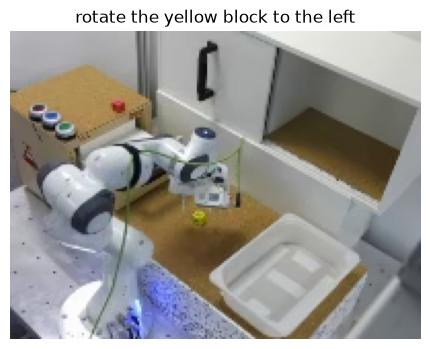

Tamaño original: (200, 150)
Tensor CLIP: torch.Size([3, 224, 224])
Tipo del tensor: torch.float32


In [13]:
def cargar_fotograma(ruta_video, indice_fotograma):
    """Lee un fotograma concreto y lo devuelve como imagen RGB de PIL."""
    captura = cv2.VideoCapture(str(ruta_video))
    captura.set(cv2.CAP_PROP_POS_FRAMES, int(indice_fotograma))
    correcto, imagen_bgr = captura.read()
    captura.release()

    if not correcto:
        raise RuntimeError(f"No se pudo leer el fotograma {indice_fotograma} de {ruta_video}")

    return Image.fromarray(cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB))

ejemplo = tabla_final.iloc[0]
imagen_ejemplo = cargar_fotograma(ejemplo["imagen"], ejemplo["fotograma_video"])
imagen_preprocesada = preprocess(imagen_ejemplo)

plt.figure(figsize=(6, 4))
plt.imshow(imagen_ejemplo)
plt.title(ejemplo["instruccion"])
plt.axis("off")
plt.show()

print(f"Tamaño original: {imagen_ejemplo.size}")
print(f"Tensor CLIP: {imagen_preprocesada.shape}")
print(f"Tipo del tensor: {imagen_preprocesada.dtype}")

## 4. Procesamiento de instrucciones con CLIP

Las instrucciones asociadas a cada `task_index` se tokenizan con el tokenizer de CLIP. En esta etapa solo se preparan los tokens; los embeddings textuales se generarán cuando el modelo los necesite.

In [14]:
instruccion_ejemplo = ejemplo["instruccion"]
tokens_ejemplo = tokenizer([instruccion_ejemplo])

print(f"Instrucción: {instruccion_ejemplo}")
print(f"Longitud máxima del tokenizer: {tokens_ejemplo.shape[1]}")
print(f"Dimensiones de los tokens: {tokens_ejemplo.shape}")
print(f"Tipo de los tokens: {tokens_ejemplo.dtype}")

Instrucción: rotate the yellow block to the left
Longitud máxima del tokenizer: 77
Dimensiones de los tokens: torch.Size([1, 77])
Tipo de los tokens: torch.int64


## 5. Representación de las acciones

La decisión para el resto del TFM es representar cada acción como un vector continuo de siete dimensiones: `[x, y, z, rx, ry, rz, gripper]`. Esta representación respeta los valores originales y evita una discretización artificial en tokens.

In [16]:
NOMBRES_ACCION = ["termination", "x", "y", "z", "rx", "ry", "rz", "gripper"]
print("Representación seleccionada: acción → vector continuo de 8 dimensiones")
print(NOMBRES_ACCION)

Representación seleccionada: acción → vector continuo de 8 dimensiones
['termination', 'x', 'y', 'z', 'rx', 'ry', 'rz', 'gripper']


## 6. División Train / Validation / Test

La división se realiza por episodios completos y no por fotogramas. De este modo, ningún frame de un mismo episodio puede aparecer en más de una partición, evitando fuga de información entre entrenamiento y evaluación.

In [17]:
PROPORCION_TRAIN = 0.80
PROPORCION_VALIDATION = 0.10
PROPORCION_TEST = 0.10

assert np.isclose(PROPORCION_TRAIN + PROPORCION_VALIDATION + PROPORCION_TEST, 1.0)

generador = np.random.default_rng(SEMILLA)
episodios_unicos = tabla_final["episode_index"].drop_duplicates().to_numpy().copy()
generador.shuffle(episodios_unicos)

n_episodios = len(episodios_unicos)
limite_train = int(PROPORCION_TRAIN * n_episodios)
limite_val = limite_train + int(PROPORCION_VALIDATION * n_episodios)

episodios_train = set(episodios_unicos[:limite_train])
episodios_val = set(episodios_unicos[limite_train:limite_val])
episodios_test = set(episodios_unicos[limite_val:])

train = tabla_final[tabla_final["episode_index"].isin(episodios_train)].reset_index(drop=True)
validation = tabla_final[tabla_final["episode_index"].isin(episodios_val)].reset_index(drop=True)
test = tabla_final[tabla_final["episode_index"].isin(episodios_test)].reset_index(drop=True)

assert episodios_train.isdisjoint(episodios_val)
assert episodios_train.isdisjoint(episodios_test)
assert episodios_val.isdisjoint(episodios_test)

resumen_particiones = pd.DataFrame({
    "partición": ["train", "validation", "test"],
    "episodios": [len(episodios_train), len(episodios_val), len(episodios_test)],
    "muestras": [len(train), len(validation), len(test)],
})
display(resumen_particiones)

# Los parámetros se estiman solo con train para poder desnormalizar sin fuga de información.
acciones_train = np.vstack(train["accion"].to_numpy()).astype(np.float32)
minimo_accion = acciones_train.min(axis=0)
maximo_accion = acciones_train.max(axis=0)
escala_accion = np.where(maximo_accion - minimo_accion == 0, 1.0, maximo_accion - minimo_accion)
parametros_normalizacion = {
    "minimo": minimo_accion,
    "maximo": maximo_accion,
    "escala": escala_accion,
}

def normalizar_accion(accion):
    """Escala una acción continua con los rangos de entrenamiento."""
    return (np.asarray(accion, dtype=np.float32) - minimo_accion) / escala_accion

def desnormalizar_accion(accion_normalizada):
    """Recupera la escala original de una acción normalizada."""
    return np.asarray(accion_normalizada, dtype=np.float32) * escala_accion + minimo_accion

accion_normalizada_ejemplo = normalizar_accion(train.loc[0, "accion"])
assert np.allclose(
    train.loc[0, "accion"],
    desnormalizar_accion(accion_normalizada_ejemplo),
    atol=1e-6
)
print("Parámetros de normalización guardados y comprobados.")

,partición,episodios,muestras
0,train,2882,190212
1,validation,360,23760
2,test,361,23826


Parámetros de normalización guardados y comprobados.


## 7. Creación del `Dataset`

`VLADataset` carga cada fotograma solo cuando se solicita, aplica el preprocesamiento de CLIP y devuelve la instrucción tokenizada junto con la acción normalizada. Esto mantiene el uso de memoria contenido en CPU.

In [18]:
class VLADataset(Dataset):
    def __init__(self, tabla, preprocess, tokenizer):
        self.tabla = tabla.reset_index(drop=True)
        self.preprocess = preprocess
        self.tokenizer = tokenizer

    def __len__(self):
        return len(self.tabla)

    def __getitem__(self, indice):
        muestra = self.tabla.iloc[indice]

        # La imagen se decodifica bajo demanda para no cargar todos los vídeos en memoria.
        imagen = cargar_fotograma(muestra["imagen"], muestra["fotograma_video"])
        imagen = self.preprocess(imagen)
        tokens = self.tokenizer([muestra["instruccion"]])[0]
        accion = torch.tensor(normalizar_accion(muestra["accion"]), dtype=torch.float32)

        return imagen, tokens, accion

train_dataset = VLADataset(train, preprocess, tokenizer)
val_dataset = VLADataset(validation, preprocess, tokenizer)
test_dataset = VLADataset(test, preprocess, tokenizer)

print(f"Muestras en train_dataset: {len(train_dataset):,}")

Muestras en train_dataset: 190,212


## 8. Creación de los `DataLoader`

Se utiliza un lote pequeño y `num_workers=0` para mantener el pipeline ligero y compatible con el entorno actual de CPU sin CUDA.

In [19]:
BATCH_SIZE = 4

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Batch size: {BATCH_SIZE}")
print(f"Batches de entrenamiento: {len(train_loader):,}")

Batch size: 4
Batches de entrenamiento: 47,553


## 9. Comprobación final del pipeline

La siguiente prueba recorre una única vez el flujo completo `Dataset → DataLoader → batch` y comprueba las dimensiones que recibirá el modelo.

In [20]:
imagenes_batch, tokens_batch, acciones_batch = next(iter(train_loader))

print(f"Shape de las imágenes: {imagenes_batch.shape}")
print(f"Shape de los tokens: {tokens_batch.shape}")
print(f"Shape de las acciones: {acciones_batch.shape}")
assert acciones_batch.shape[1] == 8
print("Pipeline de preprocesamiento preparado correctamente.")

Shape de las imágenes: torch.Size([4, 3, 224, 224])
Shape de los tokens: torch.Size([4, 77])
Shape de las acciones: torch.Size([4, 8])
Pipeline de preprocesamiento preparado correctamente.
